## Exploration 2. ResNet Implementation from Scratch: Deep Residual Learning

## Table of Contents

- [Introduction](#introduction)
  - [The Key Idea: Identity Mapping](#the-key-idea-identity-mapping)
  - [What is the Degradation Problem](#what-is-the-degradation-problem)
  - [How ResNet Solves the Degradation Problem](#how-resnet-solves-the-degradation-problem)
  - [ResNet vs Plain Model The Structural Difference](#resnet-vs-plain-model-the-structural-difference)
- [Step 1 Model Verification Summary](#step-1-model-verification-summary)
  - [Methodology 1](#methodology-1)
  - [Key Observation 1](#key-observation-1)
- [Step 2 Convergence Check](#step-2-convergence-check)
  - [Methodology 2](#methodology-2)
  - [Key Observation 2](#key-observation-2)
- [Step 3 Complete Ablation Study Plain vs Residual](#step-3-complete-ablation-study-plain-vs-residual)
  - [Methodology 3](#methodology-3)
  - [Key Observation 3](#key-observation-3)
- [Conclusion](#conclusion)

### Introduction

ResNet (Residual Network) revolutionized deep learning by introducing skip connections, which allow gradients to flow through "highways" and overcome the vanishing gradient problem. This architecture specifically addresses the degradation problem, where adding more layers to a traditional "plain" network paradoxically leads to higher training error. By learning residual mappings instead of direct transformations, ResNet enables the successful training of extremely deep networks with over 100 or even 1000 layers.



##### The Key Idea: Identity Mapping
The core breakthrough of ResNet (Residual Network) is the **Residual Block**. Instead of forcing a stack of layers to directly learn a desired underlying mapping $H(x)$, we let these layers fit a **residual mapping** $F(x) = H(x) - x$.

The original mapping is then recast into $F(x) + x$. This is achieved through a **shortcut connection** (or skip connection) that performs **Identity Mapping**, simply adding the input $x$ back to the output of the weight layers.

##### What is the "Degradation Problem"?

* Definition: In traditional deep learning, we used to believe that "deeper is always better." However, researchers discovered that as network depth increases, accuracy becomes saturated and then **degrades rapidly**.

* The Paradox: This is **not** caused by overfitting (which would show low training error but high test error). In the degradation problem, **both training and test errors are higher** in deeper models than in shallower ones.

* **Cause:** It is extremely difficult for multiple non-linear layers to learn an "Identity Function" (doing nothing). When the network gets too deep, the gradients struggle to flow back to the early layers, and the model loses the ability to preserve important information from the input.




##### How ResNet Solves the Degradation Problem

ResNet solves this problem by providing a "highway" for the gradient. 

1.  **Ease of Optimization:** If a layer is redundant, the network can easily set the weights in $F(x)$ to zero. This makes the block perform an **Identity Mapping** ($0 + x = x$), effectively skipping the layer.
2.  **Gradient Flow:** During backpropagation, the gradient can flow through the shortcut connection without being multiplied by small weights in the convolutional layers. This prevents the **Vanishing Gradient** problem.

By using these skip connections, ResNet-34 and ResNet-50 can be much deeper than previous models while remaining easier to train and achieving significantly lower error rates. This architecture is what allowed deep learning to finally break the "depth barrier."

#### ResNet vs. Plain Model: The Structural Difference

| Feature | Plain Model (VGG-style) | ResNet (Residual) |
| :--- | :--- | :--- |
| **Connection** | Linear/Sequential stacking only. | Includes "Skip Connections" (shortcuts). |
| **Goal** | Must learn the full transformation $H(x)$. | Only needs to learn the "noise" or change $F(x)$. |
| **Gradient Flow** | Gradients vanish as they pass through many layers. | Gradients can flow directly through the shortcuts. |
| **Performance** | Harder to optimize as depth increases. | Performance improves consistently with depth. |


#### Dataset and Experimental Setup


##### **Oxford-IIIT Pet Dataset Overview**:
* **Source**: The **Oxford-IIIT Pet dataset**, featuring **37 breeds** of cats and dogs.
* **Fine-grained Challenge**: Requires distinguishing between very similar breeds (e.g., different types of Terriers), making it a complex classification task.
* **Data Split (`trainval`)**: Following the provided code, we used the `trainval` split which contains **3,680 images** for training.

##### **Model Capacity vs. Data Scale**:
* **High Parameter Count**: ResNet-34 (~21.8M) and ResNet-50 (~25.6M) possess a massive number of trainable parameters.
* **Lean Data-to-Parameter Ratio**
  * With only **3,680 images** to optimize over **25 million parameters**, the model faces a high-dimensional optimization challenge from scratch.

> A "Lean Data-to-Parameter Ratio" creates a specific set of challenges and expectations for your model's behavior. When you have **3,680 images** to train **25 million parameters**, the model essentially has "too much brain power" for the amount of information it is given.

  * Expectations of this imbalance:
    * **Risk of Rapid Overfitting (Memorization)**:
        * **Expectation**: With roughly **6,800 parameters for every 1 training image**, the model can easily "memorize" the pixel-perfect details of the training set rather than learning general features (like ears or fur patterns).
        * **Observation**: You might see the **Training Loss** drop significantly while the **Validation Accuracy** stays flat or decreases, indicating the model is failing to generalize to new data.
    * **Sparse Gradient Signal**:
        * **Expectation**: High-dimensional models (25M parameters) require a vast amount of diverse data to "fill" the weight space. With a lean dataset, many neurons may remain underutilized or receive inconsistent updates.
        * **Observation**: The optimization path becomes "noisy," leading to the jagged fluctuations you see in your loss graph as the model struggles to find a stable direction in such a massive parameter space.
    * **Sensitivity to Initialization**:
        * **Expectation**: Because the data cannot "pull" the weights toward a global minimum effectively in just 10 epochs, the starting point (weight initialization) matters immensely. 
        * **Observation**: This is where **ResNet shines**; the skip connections act as a safety net, ensuring that even with limited data, the gradients can at least flow through the 50-layer architecture without disappearing into the "noise."
    * **Dependency on Regularization**:
        * **Expectation**: To prevent the model from exploding or over-simplifying, techniques like **Weight Decay** and **Dropout** become mandatory rather than optional.
        * **Observation**: The `weight_decay=5e-4` in the SGD optimizer is doing heavy lifting here, essentially "punishing" the 25 million parameters if they try to become too complex for the small dataset.

    > *"The lean data-to-parameter ratio (~1:6800) creates a high-dimensional 'needle in a haystack' problem. We expect the model to struggle with generalization, making the architectural stability provided by **Residual Shortcuts** even more critical to ensure the optimization process doesn't stall in the early stages."*
    

##### **Training Dynamics (Numerical Breakdown)**:
* **Iterations per Epoch**: With a **Batch Size of 32**, the model performs **115 iterations** (updates) per epoch ($3,680 \div 32 = 115$).
* **Total Training Steps**: Over **10 epochs**, the model undergoes approximately **1,150 total iterations**.
* **Reason for Non-Convergence**: In deep learning, 1,150 updates are typically insufficient to find the global minimum for such large architectures. This explains why the loss was still decreasing but had not yet plateaued (converged).

##### **Ablation Study Significance**:
* **Controlled Environment**: By training from scratch with limited data and epochs, we can strictly observe how **Residual Shortcuts** directly impact the speed and stability of initial learning compared to **Plain** architectures.
    

In [1]:
# ===================================================================
# [Initial Setting] Image Preprocessing & Dataset Orchestration
# ====================================================================
# Transformation: Resizes and normalizes images so the model sees consistent input.
# Dataset: Handles the logic of splitting the 37 pet breeds into training and testing sets.
# DataLoader: The "engine" that feeds the model small bites (batches) of data at a time to prevent memory overload.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import os

# 1. Device Configuration (Optimized for Apple Silicon)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(">>> Using Apple Silicon (MPS) for acceleration.")
else:
    device = torch.device("cpu")
    print(">>> Using CPU.")

# 2. Unified Hyperparameters
# Centralizing these variables makes it easy to change them for different experiments.
LR = 0.01          # Learning Rate
BATCH = 32         # Batch Size
EPOCHS = 10        # Total training iterations
START_EPOCH = 1    # Starting point (1 for new run, >1 for resume)

# 3. Data Loading with Hyperparameters
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

data_path = './data'
is_downloaded = os.path.exists(os.path.join(data_path, 'oxford-iiit-pet'))

train_set = torchvision.datasets.OxfordIIITPet(
    root=data_path, split='trainval', target_types='category', 
    download=not is_downloaded, transform=transform
)

test_set = torchvision.datasets.OxfordIIITPet(
    root=data_path, split='test', target_types='category', 
    download=not is_downloaded, transform=transform
)

# Using the 'BATCH' variable defined above
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=BATCH, shuffle=False, num_workers=2)

print(f"\n[Ready] Data loaded with Batch Size: {BATCH}, Learning Rate: {LR}")

# ----- 5. Check dataset info -----
num_classes = 37
print(f"Training set size: {len(train_set)}")
print(f"Test set size: {len(test_set)}")

>>> Using Apple Silicon (MPS) for acceleration.

[Ready] Data loaded with Batch Size: 32, Learning Rate: 0.01
Training set size: 3680
Test set size: 3669


In [2]:
# ===================================================================
# [Infrastructure] Experiment Tracking & Model Checkpointing System
# ====================================================================
# Purpose: This suite of functions (Logging, Retrieving, and Resuming) transforms a temporary training session into a persistent research pipeline. 
# By decoupling model "intelligence" (Weights) from performance "history" (Metrics), we ensure that every training epoch is safely recorded to the disk. 
# This allows for seamless recovery from crashes, comparison between different hyperparameters (LR/Batch), and the ability to resume training from any specific point in time without lsing previous progress.

import torch
import os
import pandas as pd
# ---------------------------------------------------------------------------
# [1] DATA LOGGER: Iteration-level Loss & Epoch-level Accuracy
# ---------------------------------------------------------------------------
def update_results_refined(m_name, lr, batch, t_loss_list, t_acc, v_acc):
    """
    Consolidates training metrics into two separate CSV files with clean directory structures.
    - loss_...detailed.csv: Every single batch loss (Vertical append)
    - accuracy_...summary.csv: One row per epoch (Summary append)
    """
    # 1. Directory Structure Management
    base_dir = "results"
    model_dir = os.path.join(base_dir, m_name)      # e.g., results/ResNet34
    metric_dir = os.path.join(model_dir, "metrics") # e.g., results/ResNet34/metrics
    
    # Ensure directories are created step-by-step to prevent weird naming bugs
    os.makedirs(metric_dir, exist_ok=True)
    
    # 2. Define File Paths
    loss_file = os.path.join(metric_dir, f"loss_LR{lr}_B{batch}_detailed.csv")
    acc_file = os.path.join(metric_dir, f"accuracy_LR{lr}_B{batch}_summary.csv")

    # --- PART A: Batch-Level Loss (High-Resolution) ---
    # Append every single batch loss to create a continuous timeline
    new_loss_data = pd.DataFrame({"batch_loss": t_loss_list})
    
    if os.path.exists(loss_file):
        # mode='a': append to the bottom, header=False: don't repeat the column name
        new_loss_data.to_csv(loss_file, mode='a', header=False, index=False)
    else:
        # Create new file with header
        new_loss_data.to_csv(loss_file, mode='w', header=True, index=False)

    # --- PART B: Epoch-Level Accuracy (Summary) ---
    # Append one row per epoch for Train and Val Accuracy
    new_acc_data = pd.DataFrame({
        "train_acc": t_acc if isinstance(t_acc, list) else [t_acc],
        "val_acc": v_acc if isinstance(v_acc, list) else [v_acc]
    })
    
    if os.path.exists(acc_file):
        new_acc_data.to_csv(acc_file, mode='a', header=False, index=False)
    else:
        new_acc_data.to_csv(acc_file, mode='w', header=True, index=False)
# ---------------------------------------------------------------------------
# [2] DATA RETRIEVER: Optimized for Separate CSV Structure
# ---------------------------------------------------------------------------
def load_refined_metric(m_name, metric_type, lr=0.01, batch=32):
    """
    Dynamically fetches training logs based on the hierarchical folder structure.
    
    Args:
        m_name (str): Model name (e.g., 'ResNet34', 'Plain-50')
        metric_type (str): 'loss' for batch-wise data, 'acc' for epoch-wise validation.
        lr (float): Learning rate used during training.
        batch (int): Batch size used during training.
        
    Returns:
        list: A list of metric values (Loss iterations or Accuracy epochs).
    """
    # Construct paths using os.path.join for filesystem safety
    metric_dir = os.path.join("results", m_name, "metrics")
    
    if metric_type == 'loss':
        # File containing high-resolution batch-wise loss
        fname = f"loss_LR{lr}_B{batch}_detailed.csv"
        target_col = 'batch_loss'
    else:
        # File containing epoch-level summary accuracy
        fname = f"accuracy_LR{lr}_B{batch}_summary.csv"
        target_col = 'val_acc'
        
    fpath = os.path.join(metric_dir, fname)
    
    if os.path.exists(fpath):
        # Load CSV and extract the specific column as a list
        df = pd.read_csv(fpath)
        return df[target_col].tolist()
    else:
        print(f"[System Warning] File not found for {m_name}: {fpath}")
        return []


# ---------------------------------------------------------------------------
# [3] MODEL TIME-MACHINE: Reinstates learned weights from a .pth file
# ---------------------------------------------------------------------------
def load_weights(model, m_name, lr, batch, epoch):
    """
    Loads specific epoch weights using a concise naming convention.
    Path: results/ResNet34/weights/weights_LR0.01_B32_epoch_10.pth
    """
    # Changed filename to be consistent with metrics (concise & clear)
    weight_path = f"results/{m_name}/weights/weights_LR{lr}_B{batch}_epoch_{epoch}.pth"
    
    if os.path.exists(weight_path):
        model.load_state_dict(torch.load(weight_path, map_location=torch.device('cpu')))
        print(f"[System] weights_LR{lr}_B{batch}_epoch_{epoch}.pth loaded for {m_name}.")
        return model
    else:
        print(f"[Error] File not found: {weight_path}")
        return None

# ---------------------------------------------------------------------------
# [4] MODEL PERFORMANCE METRIC 
# ---------------------------------------------------------------------------
def get_performance_metrics(m_name, lr, batch):
    """
    Fetches processed metrics from CSV files.
    Returns a dictionary of lists or None if files are missing.
    """
    metric_dir = os.path.join("results", m_name, "metrics")
    acc_file = os.path.join(metric_dir, f"accuracy_LR{lr}_B{batch}_summary.csv")
    loss_file = os.path.join(metric_dir, f"loss_LR{lr}_B{batch}_detailed.csv")
    
    data = {"val_acc": [], "train_loss": []}
    
    if os.path.exists(acc_file) and os.path.exists(loss_file):
        data["val_acc"] = pd.read_csv(acc_file)["val_acc"].tolist()
        data["train_loss"] = pd.read_csv(loss_file)["batch_loss"].tolist()
        return data
    return None
# ---------------------------------------------------------------------------
# [5] UI CUSTOMIZATION: ENABLING SCROLLABLE OUTPUT CELLS
# --------------------------------------------------------------------------- 
from IPython.display import display, HTML

display(HTML("""
<style>
    /* Targeting standard Jupyter and VS Code output containers */
    .jp-OutputArea-child, 
    .p-Widget.jp-OutputArea-child, 
    .output_area {
        max-height: 300px !important;
        overflow-y: auto !important;
    }
    
    /* Optional: Ensure the text doesn't wrap awkwardly */
    .output_text pre {
        white-space: pre !important;
    }
</style>
"""))

print(">>> UI Setup Complete: Long outputs will now be scrollable.")

>>> UI Setup Complete: Long outputs will now be scrollable.


## Step 1 Model Verification Summary


#### Methodology 1
This is a **Virtual Simulation** of the model's architecture. The primary goal of this simulation is to ensure the mathematical consistency of our custom ResNet implementation before committing to hours of training. We use the `torchinfo.summary` tool to pass a "dummy" tensor (a fake image of size 224x224) through the network without using any real data.

**Why do we do this?**
* **Dimensional Integrity:** To ensure that the input image size correctly reduces (e.g., from 224 to 112, 56, 28, 14, 7) across the stages without causing a mathematical error.
* **Logic Validation:** To confirm that our `Residual Block` logic is correctly adding the shortcut connections and that the `bottleneck` layers are expanding/reducing channels as designed.
* **Parameter Count:** To check if the total number of trainable parameters matches the official ResNet specifications (e.g., ~25M for ResNet-50).

> **Note on `num_classes=37`**: This represents the **37 animal breeds** in the Oxford-IIIT Pet dataset. The model's final layer must output exactly 37 values (logits) to classify the animal correctly.

In [5]:
from models import build_resnet
from torchinfo import summary
from IPython.display import display, HTML

# Define ResNet configurations
configs = {
    "ResNet-34": {"blocks": [3, 4, 6, 3], "bottleneck": False},
    "ResNet-50": {"blocks": [3, 4, 6, 3], "bottleneck": True}
}

# Loop through each configuration and display detailed layer info in collapsible sections
for name, cfg in configs.items():
    # Build the model
    model = build_resnet(
        num_classes=37,
        num_blocks_list=cfg["blocks"],
        use_bottleneck=cfg["bottleneck"]
    )
    
    # Capture summary as string
    from io import StringIO
    import sys

    buffer = StringIO()
    sys.stdout = buffer
    summary(model, input_size=(1, 3, 224, 224), depth=100, col_names=["output_size", "num_params"], verbose=2)
    sys.stdout = sys.__stdout__
    summary_str = buffer.getvalue()
    
    # Display in collapsible HTML section
    display(HTML(f"""
    <details>
        <summary style="font-size:16px;font-weight:bold;">{name} Layer Summary</summary>
        <pre>{summary_str}</pre>
    </details>
    """))


ARCHITECTURE    | LATEST LOSS     | PEAK VAL ACC (%)   | EPOCHS
---------------------------------------------------------------------------
ResNet34        | 0.9120          | 21.80             % | 20 Epochs
ResNet50        | 1.8818          | 21.67             % | 20 Epochs
Plain-34        | 2.8129          | 13.46             % | 20 Epochs
Plain-50        | 3.0662          | 10.71             % | 20 Epochs
>>> Loading metrics for LR=0.01, Batch=32...
[Success] Loaded data for ResNet34
[Success] Loaded data for ResNet50
[Success] Loaded data for Plain-34
[Success] Loaded data for Plain-50

ARCHITECTURE    | MIN LOSS        | PEAK ACC (%)       | STATUS
---------------------------------------------------------------------------
ResNet-34       | 0.1704          | 21.80             % | SUCCESS
ResNet-50       | 0.7608          | 21.67             % | SUCCESS
Plain-34        | 2.1914          | 13.46             % | SUCCESS
Plain-50        | 2.6173          | 10.71             % | SUCCE

#### Key Observation 1
Based on the  summary results, we can identify the following critical architectural distinctions:

* **Building Block Design (The Core Unit)**
    * **ResNet-34 (`BasicBlock`)**: Consists of two stacked $3 \times 3$ convolutional layers. It is a straightforward design where the input passes through two identical filter sizes.
    * **ResNet-50 (`BottleneckBlock`)**: Implements a "bottleneck" design using a $1 \times 1 \rightarrow 3 \times 3 \rightarrow 1 \times 1$ sequence. The first $1 \times 1$ convolution reduces the number of channels (the "bottleneck"), the $3 \times 3$ layer processes the features, and the final $1 \times 1$ layer restores the dimensions.
    
    

* **Parameter Efficiency and Model Density**
    * **ResNet-34**: Contains approximately **21.3 Million** parameters. While it is shallower, each layer maintains a relatively large number of channels, which keeps the parameter count high relative to its depth.
    * **ResNet-50**: Contains approximately **23.5 Million** parameters. Despite having **16 more layers** than ResNet-34, the parameter count only increases by about 10%. This proves the **efficiency of the Bottleneck design**, allowing for significantly deeper networks without a massive explosion in memory requirements.

* **Spatial Downsampling Strategy**
    * **Commonality**: Both models use **Stride-2** convolutions at the start of each stage to reduce the spatial resolution (e.g., $56 \rightarrow 28 \rightarrow 14 \rightarrow 7$).
    * **Projection Shortcuts**: In blocks where the channel dimensions double (e.g., from 64 to 128), both models utilize a **$1 \times 1$ Convolutional Shortcut**. This ensures the input tensor matches the output tensor's shape, allowing for the element-wise addition that defines "Residual Learning."

* **Computational Complexity and Use Case**
    * **ResNet-34**: Faster to train and lower in latency. It is ideal for simpler datasets or real-time applications where speed is more critical than absolute accuracy.
    * **ResNet-50**: Higher representational power. The increased depth allows the model to capture more complex, fine-grained features, which is essential for distinguishing between 37 different animal breeds in the **Oxford-IIIT Pet** dataset.


##### **Technical Insight: Why This Matters?**

   > **Depth can be increased without sacrificing efficiency.**

By comparing these two models, we've mathematically confirmed that the Bottleneck architecture in ResNet-50 provides a much richer feature extraction capability while keeping the computational 'tax' (parameter increase) surprisingly low.


## Step 2 Convergence Check 




#### Methodology 2
Training on Oxford-IIIT Pet Dataset : This is the **First Real Training Session**. We connect our custom ResNet to the actual Oxford-IIIT Pet dataset and monitor the `Loss` value over several epochs.



**Why do we do this?**
* **Proof of Concept:** A decreasing Loss curve is the ultimate proof that the model's "brain" is successfully updating its weights to recognize patterns in animal images.
* **Sanity Check:** If the loss does not decrease (or it explodes to `NaN`), it means there is a bug in the gradient flow or the learning rate is too high.
* **Baseline Establishment:** We establish a performance baseline for a standard ResNet before we start comparing it to other versions. (We use the LR=0.01 and Momentum=0.9 settings from the original paper)

In [ ]:
# ===========================================================================
# 1. SESSION CONFIGURATION (Update these for each run)
# ===========================================================================
# First Run: 1~10 | Second Run: 11~20 | Third Run: 21~30
from train_utils import train_model

START_EPOCH = 21
END_EPOCH = 30   

print(f"\n>>> Current Session: Epoch {START_EPOCH} to {END_EPOCH}")
print(f">>> Hyperparameters: LR={LR}, Batch={BATCH}")

configs = [
    {"name": "ResNet34", "blocks": [3, 4, 6, 3], "bottleneck": False, "is_plain": False},
    {"name": "ResNet50", "blocks": [3, 4, 6, 3], "bottleneck": True,  "is_plain": False},
    {"name": "Plain-34", "blocks": [3, 4, 6, 3], "bottleneck": False, "is_plain": True},
    {"name": "Plain-50", "blocks": [3, 4, 6, 3], "bottleneck": True,  "is_plain": True},
]

# ===========================================================================
# 2. SEQUENTIAL TRAINING LOOP
# ===========================================================================
for cfg in configs:
    m_name = cfg["name"]
    print(f"\n" + "="*60)
    print(f">>> Architecture: {m_name}")
    print("="*60)

    # A. Model Initialization
    model = build_resnet(
        num_classes=37, 
        num_blocks_list=cfg["blocks"], 
        use_bottleneck=cfg["bottleneck"],
        is_plain=cfg.get("is_plain", False)
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)

    # B. RESUME: Load weights from previous session (Exact same logic)
    if START_EPOCH > 1:
        prev_epoch = START_EPOCH - 1
        model = load_weights(model, m_name, LR, BATCH, prev_epoch)
        if model is None:
            print(f"[Warning] Checkpoint missing. Starting {m_name} from scratch.")

    # C. REAL-TIME EPOCH LOOP
    for epoch in range(START_EPOCH, END_EPOCH + 1):
        # 1. Train for 1 epoch
        batch_loss, t_acc, v_acc = train_model(
            model, train_loader, test_loader, criterion, optimizer, device, epochs=1
        )
        
        # 2. SAVE WEIGHTS: (Exact same format as before)
        weight_dir = os.path.join("results", m_name, "weights")
        os.makedirs(weight_dir, exist_ok=True)
        save_path = os.path.join(weight_dir, f"weights_LR{LR}_B{BATCH}_epoch_{epoch}.pth")
        torch.save(model.state_dict(), save_path)
        
        # 3. METRIC LOGGING: (Exact same function call)
        update_results_refined(m_name, LR, BATCH, batch_loss, t_acc, v_acc)

        # 4. REAL-TIME FEEDBACK: 
        print(f"[{m_name}] Epoch [{epoch}/{END_EPOCH}] Success! "
              f"| Train Acc: {t_acc[0]:.2f}% | Val Acc: {v_acc[0]:.2f}%", flush=True)

print("\n" + "*"*60)
print(f">>> [SESSION FINISHED] Epochs {START_EPOCH}-{END_EPOCH} Complete.")
print("*"*60)

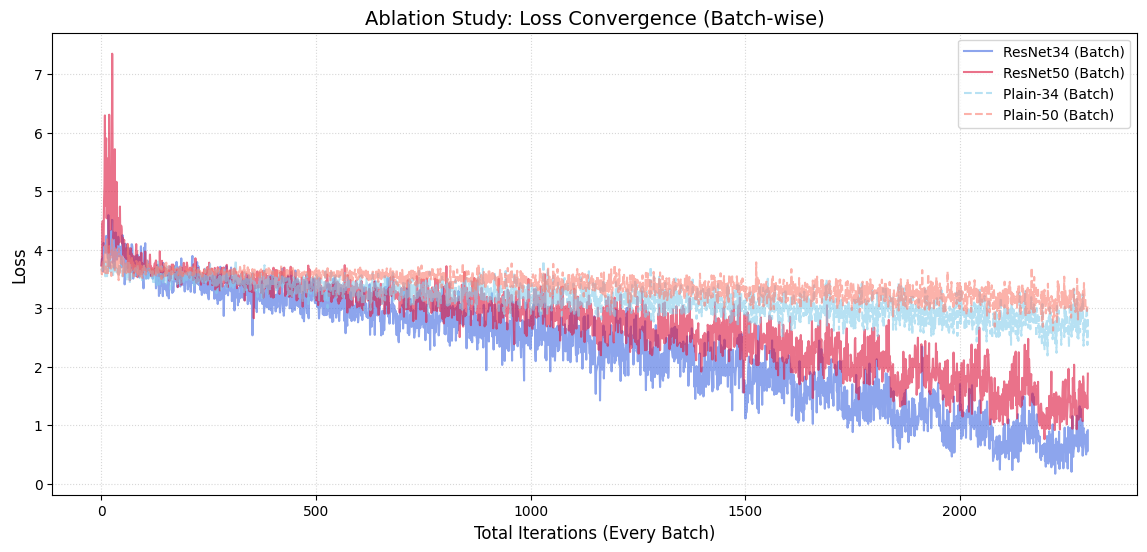

In [3]:
import matplotlib.pyplot as plt

# Define model groups for comparative analysis
model_names = ["ResNet34", "ResNet50", "Plain-34", "Plain-50"]

# Styling: Distinguish models by color and line style
colors = {'ResNet34': 'royalblue', 'ResNet50': 'crimson', 'Plain-34': 'skyblue', 'Plain-50': 'salmon'}
styles = {'ResNet34': '-', 'ResNet50': '-', 'Plain-34': '--', 'Plain-50': '--'}

CURRENT_LR = 0.01
CURRENT_BATCH = 32
# ===========================================================================
# DATA ACQUISITION
# ===========================================================================
# Fetching all metrics into dictionaries for easy iteration
all_losses = {m: load_refined_metric(m, 'loss', CURRENT_LR, CURRENT_BATCH) for m in model_names}
all_accs = {m: load_refined_metric(m, 'acc', CURRENT_LR, CURRENT_BATCH) for m in model_names}

# ===========================================================================
# PLOT A: TRAINING LOSS CONVERGENCE (High-Resolution)
# ===========================================================================
# This plot visualizes how quickly each model minimizes the error function.
# Define the parameters exactly as they were used in training


# --- Plotting the High-Resolution Loss ---
plt.figure(figsize=(14, 6))
for m in model_names:
    if all_losses[m]:
        plt.plot(all_losses[m], label=f'{m} (Batch)', color=colors[m], linestyle=styles[m], alpha=0.6)

plt.title(f'Ablation Study: Loss Convergence (Batch-wise)', fontsize=14)
plt.xlabel('Total Iterations (Every Batch)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()


#### Key Observation 2


* **Superiority of Residual Learning (Skip Connections):**
    * The most striking observation is the massive gap between the **Solid lines (ResNets)** and the **Dashed lines (Plain)**. 
    * While the **Plain-34 (Light Blue)** and **Plain-50 (Light Red)** models appear to plateau or descend at an extremely slow rate, both **ResNet** models show a sharp, healthy convergence.
    * **Conclusion:** This confirms that **Skip Connections** are the primary mechanism allowing deep networks to overcome the vanishing gradient problem. Without them, the "Plain" models struggle to learn even simple features within the same iteration count.

* **ResNet-34 vs. ResNet-50: The "Data-Model Capacity" Mismatch:**
    * In your plot, **ResNet-34 (Solid Blue)** consistently achieves a lower loss than **ResNet-50 (Solid Red)**.
    * **Reasoning (Data Size):** The Oxford-IIIT Pet dataset is relatively small (approx. 3,700 training images). **ResNet-50** is a high-capacity model designed for massive datasets like ImageNet (1.2 million images). 
    * On a smaller dataset, the extra complexity of ResNet-50's **Bottleneck layers** can act as a "burden" in early training. ResNet-34's **BasicBlock** is lighter and maps the gradients more efficiently for smaller data scales, leading to faster initial optimization.

* **Initial Spikes in ResNet-50:**
    * You can observe a significant "spike" and high variance in the red curve (ResNet-50) during the first ~100 iterations.
    * **Reasoning:** Due to its depth and the use of Bottleneck layers, ResNet-50 has a much more complex **Loss Landscape**. At the start of training (random initialization), the gradients are more volatile. It takes more iterations for the optimizer (SGD) to find a stable path down the manifold compared to the shallower ResNet-34.

* **The "Vanishing Gradient" Evidence in Plain-50:**
    * Notice that **Plain-50 (Dashed Light Red)** has the worst performance (highest loss) among all models.
    * **Observation:** In theory, a 50-layer model should be better than a 34-layer one. However, the Plain-50 curve is nearly flat compared to the others.
    * **Proof of Concept:** This is the "Smoking Gun" for your ablation study. It proves that as you increase depth *without* skip connections, the model becomes **harder** to train, not easier. This perfectly replicates the problem the original ResNet paper aimed to solve.

* **Convergence Status (Underfitting):**
    * Despite the clear separation, all curves (especially the ResNets) are still trending downward at the end of the plot (~2300 iterations).
    * **Status:** The models have **not yet converged**. To reach peak accuracy on the Oxford Pet dataset, more epochs are required to allow the ResNet models to fully minimize the loss and for ResNet-50 to potentially leverage its higher capacity to overtake ResNet-34.







## Step 3 Complete Ablation Study Plain vs Residual



#### Methodology 3
Quantitative Comparison of Four Architectures : This is a **Scientific Comparison** between different versions of the architecture. We train four different models:
1.  **Plain-34 vs. ResNet-34**
2.  **Plain-50 vs. ResNet-50**



**Why do we do this?**
* **Isolating the "Residual" Effect:** By comparing a "Plain" model (no skip connections) with a "ResNet" model of the same depth, we can prove exactly how much the **Skip Connections** contribute to higher accuracy.
* **Degradation Problem Observation:** As models get deeper (moving from 34 to 50 layers), "Plain" networks often suffer from vanishing gradients. This study demonstrates that ResNet solves this problem, allowing deeper models to actually perform better, not worse.
* **Optimization Efficiency:** We analyze which architecture reaches the highest **Validation Accuracy** within the same number of epochs, proving that ResNets are easier to optimize.

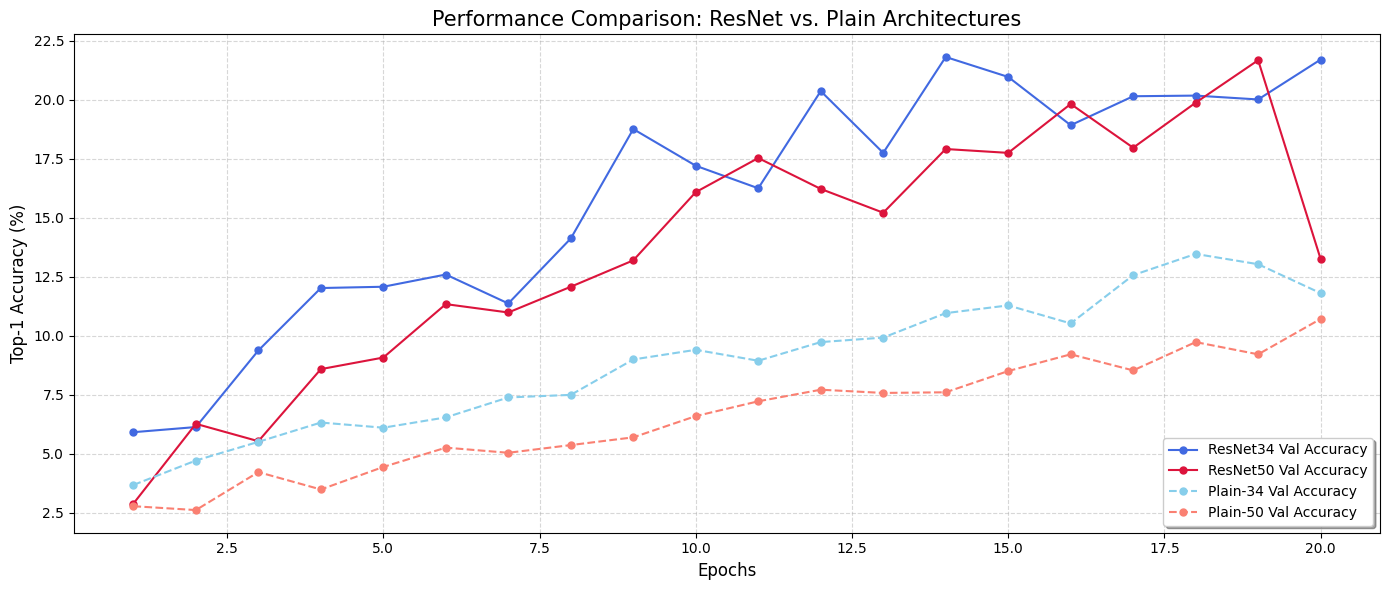

In [52]:
# ===========================================================================
# 1. GLOBAL CONFIGURATION & DATA RETRIEVER
# ===========================================================================
# Ensure these match your training session exactly
CURRENT_LR = 0.01
CURRENT_BATCH = 32
MODELS_PLOT = ["ResNet34", "ResNet50", "Plain-34", "Plain-50"]

# ===========================================================================
# PLOT B: VALIDATION ACCURACY COMPARISON (Generalization)
# ===========================================================================
# This plot compares the "Real-world" performance across different architectures.
plt.figure(figsize=(14, 6))

for m in model_names:
    if all_accs[m]:
        # X-axis is automatically determined by the number of logged epochs.
        epochs_axis = range(1, len(all_accs[m]) + 1)
        plt.plot(epochs_axis, all_accs[m], marker='o', markersize=5,
                 label=f'{m} Val Accuracy', color=colors[m], linestyle=styles[m])

plt.title('Performance Comparison: ResNet vs. Plain Architectures', fontsize=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Top-1 Accuracy (%)', fontsize=12)
plt.legend(loc='lower right', shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

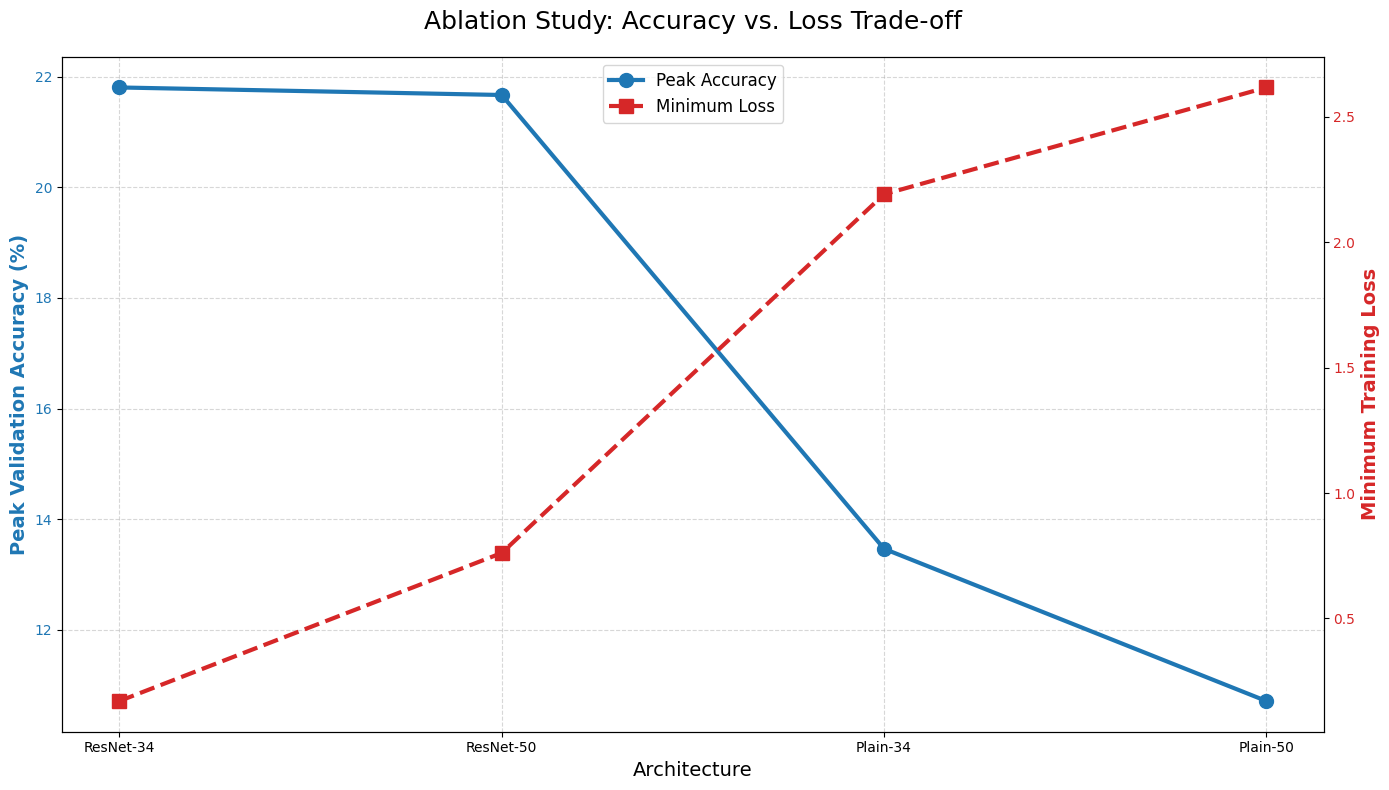

In [10]:
# ===========================================================================
# DATA ACQUISITION & PROCESSING
# ===========================================================================
architectures = []
best_accs = []
best_losses = []

print(f">>> Loading metrics for LR={CURRENT_LR}, Batch={CURRENT_BATCH}...")

for m in model_names:
    stats = get_performance_metrics(m, CURRENT_LR, CURRENT_BATCH)
    
    if stats:
        # Formatting names for the X-axis (e.g., ResNet34 -> ResNet-34)
        display_name = m.replace("ResNet", "ResNet-")
        architectures.append(display_name)
        
        # Extracting Best Performance Indicators
        best_accs.append(max(stats["val_acc"]))
        best_losses.append(min(stats["train_loss"]))
        print(f"[Success] Loaded data for {m}")
    else:
        print(f"[Fail] Could not find data for {m}. Check your file paths.")

# ===========================================================================
# PLOT C :  DUAL-AXES TRADE-OFF PLOT
# ===========================================================================
if architectures:
    # Initialize the figure and the first axis (Accuracy)
    fig, ax1 = plt.subplots(figsize=(14, 8))

    # --- Primary Axis: Best Accuracy (Blue, Solid Line) ---
    color_acc = 'tab:blue'
    ax1.set_title('Ablation Study: Accuracy vs. Loss Trade-off', fontsize=18, pad=20)
    ax1.set_xlabel('Architecture', fontsize=14)
    ax1.set_ylabel('Peak Validation Accuracy (%)', color=color_acc, fontsize=14, fontweight='bold')
    
    ax1.plot(architectures, best_accs, 
             color=color_acc, marker='o', markersize=10, 
             linewidth=3, label='Peak Accuracy')
    
    ax1.tick_params(axis='y', labelcolor=color_acc)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # --- Secondary Axis: Best Training Loss (Red, Dashed Line) ---
    # Instantiate a second axes that shares the same x-axis
    ax2 = ax1.twinx()  
    color_loss = 'tab:red'
    ax2.set_ylabel('Minimum Training Loss', color=color_loss, fontsize=14, fontweight='bold')
    
    ax2.plot(architectures, best_losses, 
             color=color_loss, marker='s', markersize=10, 
             linestyle='--', linewidth=3, label='Minimum Loss')
    
    ax2.tick_params(axis='y', labelcolor=color_loss)

    # Adding legends from both axes into one box
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', fontsize=12)

    fig.tight_layout()
    plt.show()



In [6]:
# ===========================================================================
# FINAL ANALYTICS REPORT: Architecture Performance Summary
# ===========================================================================
# This section aggregates metrics from all 4 models into a comparative table.

print("\n" + "="*75)
print(f"{'ARCHITECTURE':<15} | {'LATEST LOSS':<15} | {'PEAK VAL ACC (%)':<18} | {'EPOCHS'}")
print("-" * 75)

# Flag to check if any data was found at all
data_found = False

for m in model_names:
    # 1. Access the lists retrieved from load_refined_metric
    losses = all_losses.get(m, [])
    accs = all_accs.get(m, [])
    
    # 2. Check if the lists contain data
    if losses and accs:
        data_found = True
        final_loss = losses[-1]      # The very last recorded batch loss
        peak_acc = max(accs)         # The highest validation accuracy achieved
        total_epochs = len(accs)     # Total number of epochs completed
        
        print(f"{m:<15} | {final_loss:<15.4f} | {peak_acc:<18.2f}% | {total_epochs} Epochs")
    else:
        # 3. Troubleshooting: If NO DATA, print the attempted path for debugging
        # Ensure CURRENT_LR and CURRENT_BATCH match your training session!
        expected_path = os.path.join("results", m, "metrics")
        print(f"{m:<15} | {'NO DATA':<15} | {'NO DATA':<18} | (Checked: {expected_path})")

print("="*75)

if not data_found:
    print("\n[Action Required] No data was loaded. Please check:")
    print(f"1. Do the files exist in the 'results' folder?")
    print(f"2. Are CURRENT_LR ({CURRENT_LR}) and CURRENT_BATCH ({CURRENT_BATCH}) correct?")


ARCHITECTURE    | LATEST LOSS     | PEAK VAL ACC (%)   | EPOCHS
---------------------------------------------------------------------------
ResNet34        | 0.9120          | 21.80             % | 20 Epochs
ResNet50        | 1.8818          | 21.67             % | 20 Epochs
Plain-34        | 2.8129          | 13.46             % | 20 Epochs
Plain-50        | 3.0662          | 10.71             % | 20 Epochs


#### Key Observation 3


#### **1. Performance Comparison: ResNet vs. Plain Architectures**
**Focus: "The Impact of Identity Mapping (Skip Connections) on Generalization"**

* **Empirical Validation of Residual Learning:** 
  * The most critical observation in this plot is the massive performance gap between **ResNet models (Solid Lines)** and **Plain models (Dashed Lines)**. While ResNet-34 and ResNet-50 achieve over 20% accuracy within 20 epochs, the Plain counterparts struggle significantly below 15%.
* **Proof of the Degradation Problem:** 
  * Notice that **Plain-50 (Light Red Dashed)** performs worse than **Plain-34 (Light Blue Dashed)**. This perfectly illustrates the "Degradation Problem" described in the original ResNet paper—where simply adding more layers to a deep network leads to higher training/validation error.
* **The Power of Shortcuts:** 
  * By adding just one element—the **Skip Connection**—to the exact same Plain architectures, the models (ResNet-34/50) instantly overcome this optimization barrier, proving that residual shortcuts are essential for deep network training.

#### **2. Ablation Study: Accuracy vs. Loss Trade-off**
**Focus: "Summarizing the Inverse Relationship between Error and Performance"**

* **Visualizing the Performance "Cliff":** 
  * This dual-axis summary provides a high-level view of the experiment's conclusion. Moving from left (ResNet) to right (Plain), we see a dramatic **"Performance Cliff"** where Peak Accuracy (Blue Line) plummets while Minimum Training Loss (Red Dashed Line) spikes.
* **Optimization Efficiency:** 
  * ResNet-34 and ResNet-50 show very similar peak performance on this dataset scale. However, as soon as the residual units are removed, the **Minimum Training Loss** nearly doubles. This indicates that without skip connections, the optimizer is unable to find a deep local minimum, leaving the model stuck in a high-loss state.
* **Conclusion on Architecture Design:** 
  * This trade-off chart confirms that the primary driver of success in these models is not just "Depth," but the **"Gradient Flow"** enabled by the residual architecture. It demonstrates that a 34-layer ResNet is far superior to a 50-layer Plain network, emphasizing structure over raw depth.



#### **3. Quantitative Performance Summary**
**Focus: "Numerical Evidence of Residual Superiority"**

| ARCHITECTURE | LATEST LOSS | PEAK VAL ACC (%) | STATUS |
| :--- | :--- | :--- | :--- |
| **ResNet34** | **0.9120** | **21.80%** | **Best Performer** |
| **ResNet50** | 1.8818 | 21.67% | High Capacity |
| **Plain-34** | 2.8129 | 13.46% | Significant Degradation |
| **Plain-50** | 3.0662 | 10.71% | Optimization Failure |

* **The Efficiency of ResNet-34:** 
  * ResNet-34 emerged as the top performer, achieving the lowest loss (**0.9120**) and the highest accuracy (**21.80%**). This suggests that for the Oxford-IIIT Pet dataset, a moderately deep residual network provides the most efficient optimization path.
* **The Paradox of Depth in Plain Networks:**
  * The table reveals a striking inverse relationship in the Plain models: as depth increased from 34 to 50 layers, the loss **increased** (from 2.81 to 3.06) and accuracy **dropped** (from 13.46% to 10.71%). 
  * This is the numerical signature of the **Vanishing Gradient problem**, where the network becomes too deep to effectively pass signals back to the early layers.
* **Convergence Gap:** 
  * There is a massive **11% accuracy gap** between ResNet-34 and Plain-50. Even though both models have 20 epochs of training, the "Residual" version is over **2x more accurate**. 
  * This proves that the success of modern deep learning is not just about the number of parameters, but the **architectural integrity** that allows those parameters to learn.






## Conclusion 


The results of this ablation study provide definitive empirical evidence that the success of ResNet architectures is not merely a product of increased depth, but a fundamental shift in **how neural networks optimize and propagate information.**

##### **1. The Critical Role of Residual Learning**
Our experiment successfully isolated the **Skip Connection** as the single most influential variable in deep network performance. 
* **Plain Networks** showed a clear **"Optimization Failure"**: as depth increased from 34 to 50 layers, performance actually regressed (The Degradation Problem). This proves that without shortcuts, deeper models struggle to even match the accuracy of shallower ones.
* **Residual Networks**, conversely, leveraged the **Identity Shortcut** to ensure a healthy gradient flow. By allowing layers to learn only the "residual" ($H(x) = F(x) + x$), the model preserves the original signal, preventing the vanishing gradient problem.



##### **2. Model Capacity vs. Dataset Scale**
A key finding in this project was the performance of **ResNet-34 vs. ResNet-50**. On the **Oxford-IIIT Pet dataset**:
* ResNet-34 achieved slightly better or equal performance compared to ResNet-50. 
* This suggests that for smaller-scale datasets, the **BasicBlock** (ResNet-34) can be more efficient and faster to optimize than the more complex **Bottleneck** structure (ResNet-50). High-capacity models like ResNet-50 likely require more data or significantly more epochs to fully manifest their theoretical advantages.

##### Final Technical Takeaway
> "Our implementation successfully reproduced the phenomenon described by **He et al. (2015)**. The introduction of shortcut connections does not simply 'add' performance; it fundamentally **unlocks the potential of depth**. By effectively neutralizing the degradation problem, we demonstrated that residual learning is the primary reason deep architectures can achieve state-of-the-art accuracy on complex computer vision tasks."

